# Proof-of-Concept 4-Parameter Model K-Fold Cross-Validation

This notebook uses K-Fold Cross Validation on a small proof-of-concept emulator that predicts the **binned kSZ angular power spectrum (Dl)** using 4 reionization params ($z_{mean}$, $\alpha$, $k_b$, $b_0$).

In [ ]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
SRC = ROOT / "src/"
sys.path.insert(0, str(SRC))

import numpy as np
import torch
import matplotlib.pyplot as plt
plt.rc("figure", figsize=(6, 4), dpi=150)

from emulator.models.poc_four_params import POCEmulatorFourParamsV2
from emulator.data.dataloaders import load_training_arrays
from emulator.training.train_loop import FitConfig
from emulator.data.dataloaders import DataLoaderConfig
from emulator.training.kfold_cv import KFoldConfig, kfold_cross_validate

## Condensed HDF5 Path
The condensed v6 simulation dataset is constructed with: $Y = \ln(D_\ell)$

In [9]:
H5_PATH = Path("../data/processed/condensed_v6.h5").resolve()

## Define Model | Optimizer | Configs

In [10]:
def model_builder() -> torch.nn.Module:
    return POCEmulatorFourParams()

def optimizer_builder(model: torch.nn.Module) -> torch.optim.Optimizer:
    return torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

loss_fn = torch.nn.MSELoss()

dlcfg = DataLoaderConfig(
    batch_size=32,
    seed=42,
    shuffle_train=True,
    normalize_X=True,
    normalize_Y=False
)

fitcfg = FitConfig(
    epochs=200,
    device="mps",
    early_stopping_patience=25,
    gradient_clipping=None
)

kcfg = KFoldConfig(
    k=5,
    seed=42,
    return_histories=True
)

## Run K-Fold Cross Validation

In [11]:
result = kfold_cross_validate(
    H5_PATH,
    model_builder=model_builder,
    optimizer_builder=optimizer_builder,
    loss_fn=loss_fn,
    kfold_config=kcfg,
    dl_config=dlcfg,
    fit_config=fitcfg
)


=== Fold 1/5 | train=800 val=200 ===
Epoch 001: train=0.282024, val=0.245961
Epoch 002: train=0.198886, val=0.163878
Epoch 003: train=0.113213, val=0.085067
Epoch 004: train=0.053227, val=0.037626
Epoch 005: train=0.023895, val=0.018975
Epoch 006: train=0.015395, val=0.014474
Epoch 007: train=0.012454, val=0.012451
Epoch 008: train=0.010691, val=0.011240
Epoch 009: train=0.009513, val=0.010513
Epoch 010: train=0.008760, val=0.010128
Epoch 011: train=0.008211, val=0.009436
Epoch 012: train=0.007736, val=0.009166
Epoch 013: train=0.007447, val=0.008905
Epoch 014: train=0.007184, val=0.008821
Epoch 015: train=0.007038, val=0.008380
Epoch 016: train=0.006811, val=0.008225
Epoch 017: train=0.006624, val=0.008099
Epoch 018: train=0.006569, val=0.007943
Epoch 019: train=0.006469, val=0.007677
Epoch 020: train=0.006266, val=0.007614
Epoch 021: train=0.006259, val=0.007327
Epoch 022: train=0.006137, val=0.007501
Epoch 023: train=0.006052, val=0.007160
Epoch 024: train=0.005986, val=0.007069
Ep

## K-Fold CV Results

In [12]:
result.keys()
print(f"Min Validation Loss Per Fold: {result['fold_best_val']}")
print(f"Mean Validation Loss: {result['mean_best_val']}")
print(f"STD Validation Loss: {result['std_best_val']}")

Min Validation Loss Per Fold: [0.004017135128378868, 0.004186456669121981, 0.0035743582714349033, 0.0034508033422753215, 0.004071329180151224]
Mean Validation Loss: 0.0038600165182724596
STD Validation Loss: 0.0003259442161607902


## Plot Learning Curves Per Fold

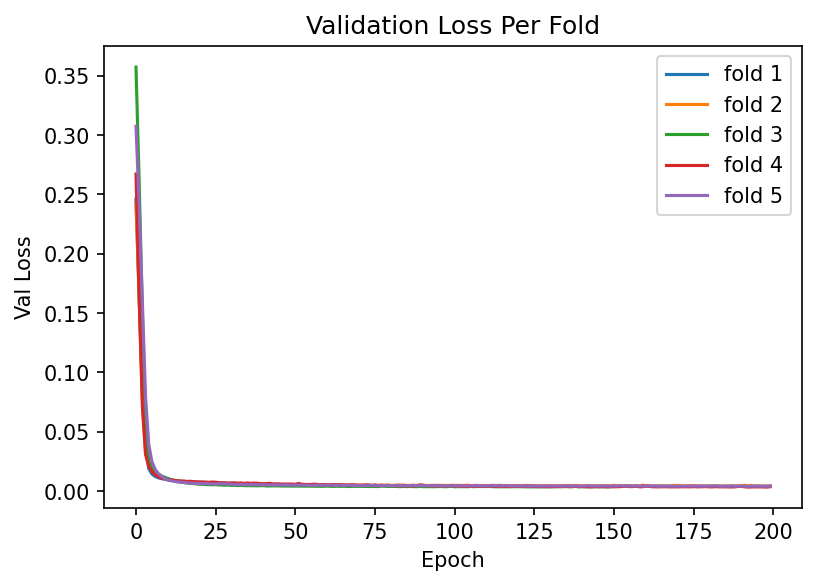

In [13]:
histories = result["histories"]

plt.figure()
for i, h in enumerate(histories):
    plt.plot(h["val_loss"], label=f"fold {i+1}")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.title("Validation Loss Per Fold")
plt.legend()
plt.show()

## Best Validation Loss Per Fold

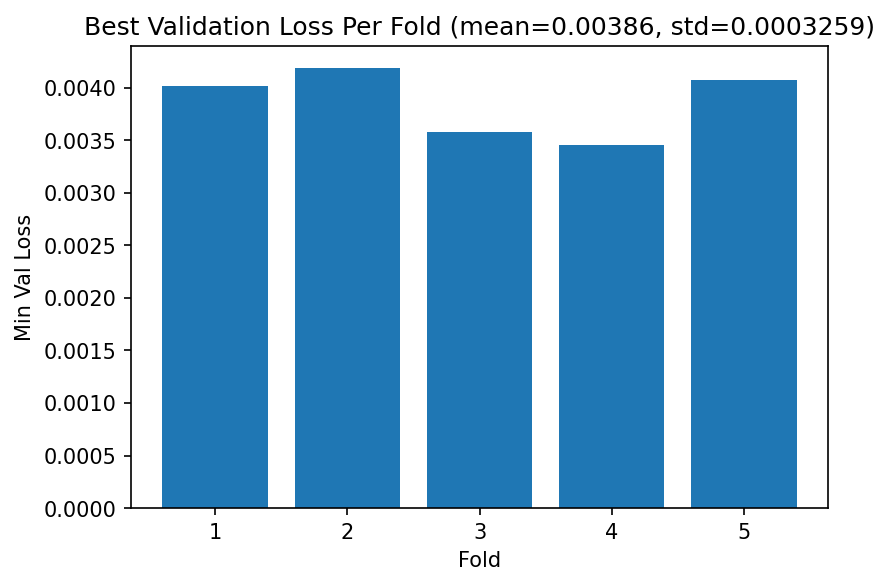

In [14]:
best_vals = np.array(result["fold_best_val"], dtype=float)
plt.figure()
plt.bar(np.arange(1, len(best_vals)+1), best_vals)
plt.xlabel("Fold")
plt.ylabel("Min Val Loss")
plt.title(f"Best Validation Loss Per Fold (mean={result['mean_best_val']:.4g}, std={result['std_best_val']:.4g})")
plt.show()